# QCD vs ttbar: per-model tri-jet mass spectra

Overlays, for every evaluator model, the tri-jet invariant mass spectrum of the
combined QCD HT slices with the ttbar spectrum. Inputs are the two ROOT files
written by `scripts/make_histograms.py`:

```bash
# QCD: all slices, weighted by lumi * xs_pb / n_original
python scripts/make_histograms.py ../dataset_evaluated.json -o qcd_spectra.root

# ttbar: unweighted
python scripts/make_histograms.py evaluated_TTto4Q_*.root -o ttbar_spectra.root
```

The models are discovered from the `h_mass_<Model>` keys in the files, so new
evaluator models show up here automatically.

The ttbar file is filled **unweighted**; set `TTBAR_WEIGHT` below to normalise
it. To put ttbar on the same footing as the xsec-weighted QCD slices use
`TTBAR_WEIGHT = LUMI_PB * XS_TTBAR_PB / N_ORIGINAL_TTBAR`, with the same
`LUMI_PB` used when making the QCD file (`--lumi`, default 1.0).

In [ ]:
import re

import numpy as np
import uproot
import matplotlib.pyplot as plt

In [ ]:
# Outputs of scripts/make_histograms.py (paths relative to notebooks/).
QCD_FILE = "../qcd_Jul30_masym0.3_HT550.root"
QCD_FILEgt = "../qcd_Jul30_masym0.3_HT550_gte6j.root"
# QCD_FILE_03 = "../qcd_Jul6_masym0.3.root"
MIXED_FILE = "../pseudo_5fps_Jul30_masym0.3_HT550.root"
MIXED_FILE_2 = "../pseudo_2fps_Jul30_masym0.3_HT550.root"

MIXED_FILE_3 = "../mixed_spectra.root"

DENSITY = True


## Load the histograms

Every `h_mass_<Model>` TH1 in each file is read back as a `hist.Hist`
(`Weight` storage, so the Sumw2 errors survive). Models present in only one of
the two files are reported and skipped.

In [3]:
HIST_KEY_RE = re.compile(r"^h_mass_(.+)$")


def load_mass_hists(path):
    """{model: hist.Hist} for every h_mass_<Model> histogram in the file."""
    out = {}
    with uproot.open(path) as f:
        for key in f.keys(cycle=False):
            m = HIST_KEY_RE.match(key)
            if m:
                out[m.group(1)] = f[key].to_hist()
    if not out:
        raise ValueError(f"No h_mass_* histograms found in {path}")
    return out


def integral(h):
    s = h.sum()
    return getattr(s, "value", s)  # Weight storage -> WeightedSum.value


qcd_hists = load_mass_hists(QCD_FILE)
qcd_hists_gt = load_mass_hists(QCD_FILEgt)
mixed_hists = load_mass_hists(MIXED_FILE)
mixed_hists_2 = load_mass_hists(MIXED_FILE_2)

models = sorted(set(qcd_hists) & set(mixed_hists))
skipped = sorted(set(qcd_hists) ^ set(mixed_hists))
print(f"models in both files: {models}")
if skipped:
    print(f"only in one file (skipped): {skipped}")

models in both files: ['CombSolver', 'CombSolverMasym', 'Mass_Asymmetry', 'SPANet']


## Overlay per model

QCD (filled-band errors) vs ttbar scaled by `TTBAR_WEIGHT`. Log y whenever
there is content -- the xsec-weighted QCD spectrum is steeply falling.

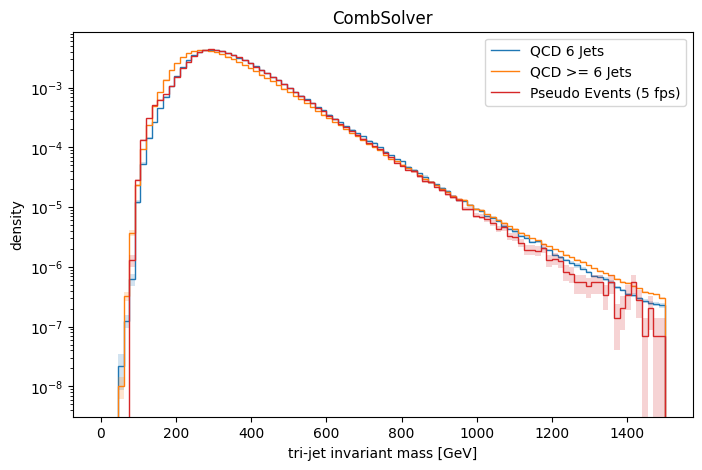

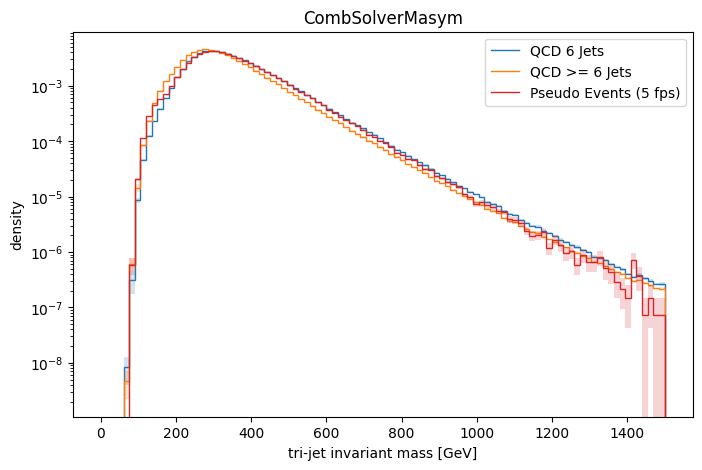

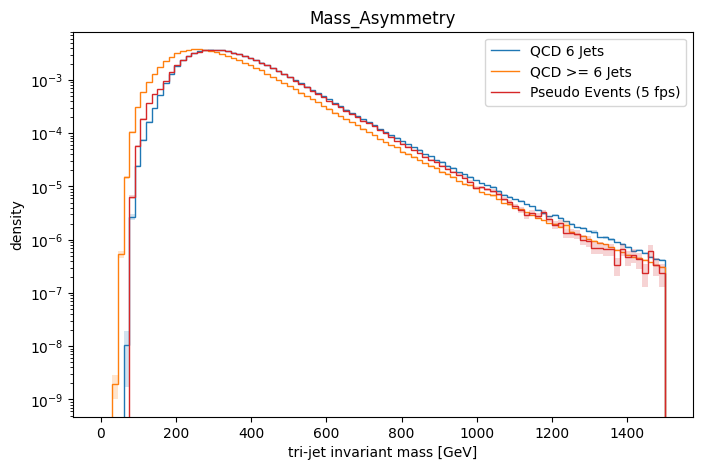

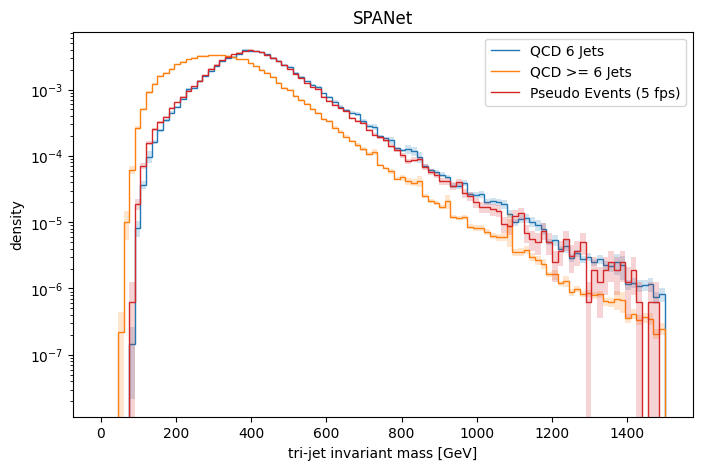

In [10]:
def step_with_band(ax, h, scale, label, color, density=False):
    """Step outline + stat-error band; returns the plotted bin values."""
    edges = h.axes[0].edges
    values = h.values() * scale
    variances = h.variances()
    variances = (variances if variances is not None else h.values()) * scale**2
    errors = np.sqrt(variances)
    if density:
        norm = values.sum() * (edges[1] - edges[0])
        if norm > 0:
            values, errors = values / norm, errors / norm
    ax.stairs(values, edges, label=label, color=color)
    pad = lambda a: np.append(a, a[-1])  # step='post' needs len(edges) points
    ax.fill_between(edges, pad(values - errors), pad(values + errors),
                    step="post", color=color, alpha=0.2, linewidth=0)
    return values


for model in models:
    fig, ax = plt.subplots(figsize=(8, 5))
    v_qcd = step_with_band(ax, qcd_hists[model], 1.0,
                           "QCD 6 Jets", "tab:blue", DENSITY)
    v_qcd_gt = step_with_band(ax, qcd_hists_gt[model], 1.0,
                            "QCD >= 6 Jets", "tab:orange", DENSITY)
    v_tt = step_with_band(ax, mixed_hists[model], 1.0,
                          f"Pseudo Events (5 fps)", "tab:red", DENSITY)
    # v_mix = step_with_band(ax, mixed_hists_2[model], 1.0,
    #                       f"Pseudo Events (2 fps)", "tab:green", DENSITY)
    #if max(v_qcd.max(), v_tt.max()) > 0:
    ax.set_yscale("log")
    ax.set_xlabel("tri-jet invariant mass [GeV]")
    ax.set_ylabel("density" if DENSITY else "weighted entries")
    ax.set_title(model)
    ax.legend()
    plt.savefig(f"plots_26_07_28/mass_{model}.pdf")
plt.show()